<a href="https://colab.research.google.com/github/wmdeneth/Sri-lanka-weather-prediction/blob/main/5th_sem_ml_group_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# We’re Building

we are building a machine learning system that:

Takes daily weather data in Sri Lanka

Uses features like:

- Temperature

- Humidity

- Rainfall

- Wind Speed

- Pressure

- Cloud cover

Predicts the weather condition:

☀️ Sunny

☁️ Cloudy

🌧️ Rainy

And we’ll compare:

- Logistic Regression

- Random Forest

Then evaluate which model works better using:

Accuracy
/F1-score

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("tharindumadhusanka9/sri-lanka-weather-data-for-all-districts")
print("Path to dataset files:", path)

100%|██████████| 4.96M/4.96M [00:00<00:00, 58.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tharindumadhusanka9/sri-lanka-weather-data-for-all-districts/versions/1


In [2]:
import os
print(os.listdir(path))

['weatherData.csv', 'locationData.csv']


In [3]:
import os
import pandas as pd

weather_file = os.path.join(path, "weatherData.csv")
df = pd.read_csv(weather_file)

print(df.head())
print(df.info())
print(df.columns)


   location_id      date  weather_code (wmo code)  temperature_2m_max (°C)  \
0            0  1/1/2010                        1                     30.1   
1            0  1/2/2010                       51                     30.1   
2            0  1/3/2010                       51                     29.6   
3            0  1/4/2010                        2                     28.9   
4            0  1/5/2010                        1                     28.1   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     22.6                      26.0   
1                     23.7                      26.3   
2                     23.1                      26.0   
3                     23.1                      25.7   
4                     21.3                      24.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           34.5                           25.0   
1                           33.9                           2

In [4]:
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder (used if target labels are categorical)

# -----------------------------
# Select input features (X)
# -----------------------------
# These are the weather-related columns used as input to the ML model
X = df[['temperature_2m_max (°C)',
        'temperature_2m_min (°C)',
        'temperature_2m_mean (°C)',
        'apparent_temperature_max (°C)',
        'apparent_temperature_min (°C)',
        'apparent_temperature_mean (°C)',
        'precipitation_sum (mm)',
        'rain_sum (mm)',
        'wind_speed_10m_max (km/h)',
        'wind_gusts_10m_max (km/h)']]

# -----------------------------
# Select target variable (y)
# -----------------------------
# This is the label we want the model to predict (weather condition code)
y = df['weather_code (wmo code)']

# -----------------------------
# Encode target if needed (Optional)
# -----------------------------
# If the target was text labels (e.g., "Sunny", "Rainy"), we would use LabelEncoder.
# In this dataset, weather_code is already numeric, so encoding is not required.
# encoder = LabelEncoder()
# y = encoder.fit_transform(y)

# -----------------------------
# Print basic information
# -----------------------------
# Print the shape of feature matrix (rows, columns)
print("Features shape:", X.shape)

# Print the shape of target vector (rows,)
print("Target shape:", y.shape)

# Print unique target classes (different weather codes)
print("Target classes:", y.unique())


Features shape: (142371, 10)
Target shape: (142371,)
Target classes: [ 1 51  2  3 53 61 63  0 65 55]


In [5]:
# Function to map codes to categories
def map_weather(code):
    if code in [0, 1]:
        return "Sunny"
    elif code in [2, 3, 51, 53, 55]:
        return "Cloudy"
    elif code in [61, 63, 65, 80, 81, 82]:
        return "Rainy"
    else:
        return "Other"  # Ignore rare codes

# Apply mapping
y_mapped = y.apply(map_weather)

# Remove rows with 'Other'
mask = y_mapped != "Other"
X = X[mask]
y_mapped = y_mapped[mask]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_mapped)

print("Classes after mapping:", le.classes_)
print("Number of samples:", len(y_encoded))


Classes after mapping: ['Cloudy' 'Rainy' 'Sunny']
Number of samples: 142371


In [6]:
from sklearn.model_selection import train_test_split

# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 113896
Testing samples: 28475


In [7]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check first 5 rows after scaling
print(X_train_scaled[:5])


[[ 0.53786596  0.62505663  0.53131523  0.72721688  0.5810945   0.72151471
   0.0165803   0.0165803  -0.66766879 -0.19077762]
 [ 2.39129828  1.16329134  1.75327515  1.87745838  0.98749858  1.47954687
  -0.38447644 -0.38447644 -0.14095893  0.33108615]
 [ 0.35850154  0.02350019  0.0561086   0.63136342  0.34203327  0.48626335
  -0.04211093 -0.04211093 -1.03343953 -0.55864879]
 [ 0.35850154  1.22661307  0.90469187 -0.01564743  0.55718838  0.30329007
  -0.53120451 -0.53120451  1.90735721  1.5373614 ]
 [ 1.37489991  0.59339577  1.00652187  1.49404455  0.74843735  1.06132223
  -0.45294954 -0.45294954 -0.38968303 -0.55864879]]


In [8]:
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train on scaled data
lr_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression training complete!")


Logistic Regression training complete!


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train on original (unscaled) data
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest training complete!")


Random Forest training complete!


In [10]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Logistic Regression
print("🔵 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Random Forest
print("\n🟢 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


🔵 Logistic Regression Results
Accuracy: 0.8580860403863038
F1 Score: 0.8426601986158222
              precision    recall  f1-score   support

      Cloudy       0.84      0.94      0.89     16699
       Rainy       0.92      0.87      0.89      9525
       Sunny       0.61      0.20      0.30      2251

    accuracy                           0.86     28475
   macro avg       0.79      0.67      0.69     28475
weighted avg       0.85      0.86      0.84     28475


🟢 Random Forest Results
Accuracy: 0.8708340649692713
F1 Score: 0.8664994877624015
              precision    recall  f1-score   support

      Cloudy       0.87      0.91      0.89     16699
       Rainy       0.91      0.90      0.91      9525
       Sunny       0.60      0.43      0.50      2251

    accuracy                           0.87     28475
   macro avg       0.80      0.75      0.77     28475
weighted avg       0.86      0.87      0.87     28475



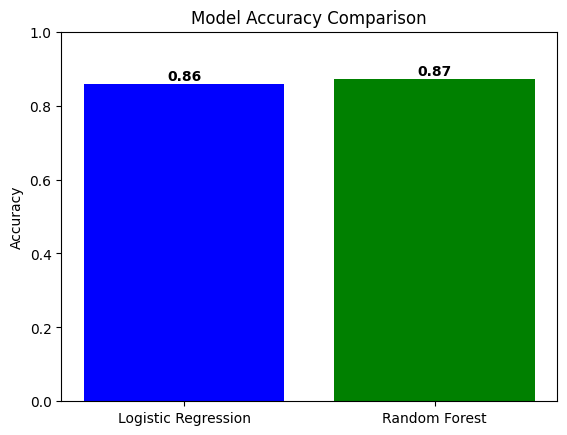

In [11]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracy = [0.858, 0.871]

plt.bar(models, accuracy, color=['blue', 'green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


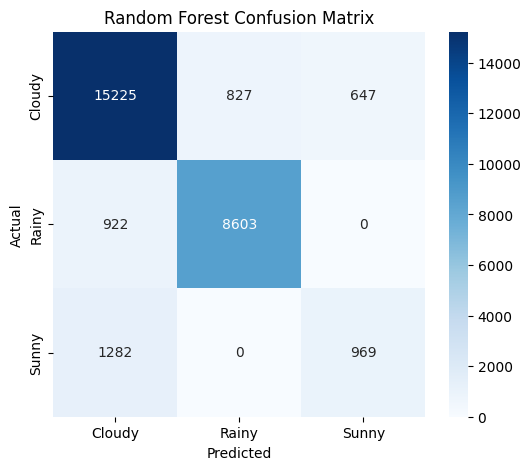

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Project Goal

Your project aims to build a machine learning system that predicts weather conditions (Sunny, Cloudy, Rainy) in Sri Lanka. You're using daily weather data with features like temperature, humidity, rainfall, wind speed, and cloud cover. You plan to compare Logistic Regression and Random Forest models, evaluating them based on Accuracy and F1-score.

### Step 1: Data Download

You used `kagglehub` to download the 'sri-lanka-weather-data-for-all-districts' dataset. The output `Path to dataset files: /kaggle/input/sri-lanka-weather-data-for-all-districts` confirms that the dataset has been successfully downloaded and is accessible at this local path.

### Step 2: List Dataset Files

To see what files are inside the downloaded dataset, you used `os.listdir(path)`. The output `['weatherData.csv', 'locationData.csv']` shows that the dataset contains two CSV files: `weatherData.csv` and `locationData.csv`.

### Step 3: Load and Inspect Weather Data

You loaded `weatherData.csv` into a pandas DataFrame named `df`.

*   `print(df.head())` displayed the first 5 rows, giving you a quick look at the data structure and initial values.
*   `print(df.info())` provided a summary of the DataFrame, including the number of entries (142,371 rows), the number of columns (21), data types for each column, and non-null counts. This is crucial for identifying missing values and understanding data types.
*   `print(df.columns)` listed all column names, which helps in feature selection.

### Step 4: Feature and Target Variable Selection

You selected relevant columns for your features (`X`) based on your project description (temperature, apparent temperature, precipitation, rain, wind speed, wind gusts). The target variable (`y`) was set to `weather_code (wmo code)`.

The output confirmed:
*   `Features shape: (142371, 10)`: There are 142,371 samples and 10 features.
*   `Target shape: (142371,)`: There are 142,371 target values.
*   `Target classes: [ 1 51  2  3 53 61 63  0 65 55]`: These are the unique weather codes present in the dataset, which need to be mapped to more descriptive categories.

### Step 5: Map Weather Codes to Categories

You defined a function `map_weather` to transform the WMO weather codes into three main categories: "Sunny", "Cloudy", and "Rainy". Any other codes are categorized as "Other". You then applied this mapping to your target variable `y` to create `y_mapped`.

Rows categorized as "Other" were removed from both `X` and `y_mapped` to focus on the primary weather conditions. Finally, you used `LabelEncoder` to convert these categorical labels ("Sunny", "Cloudy", "Rainy") into numerical labels (`y_encoded`), which is required by most machine learning algorithms.

The output `Classes after mapping: ['Cloudy' 'Rainy' 'Sunny']` and `Number of samples: 142371` confirm the successful transformation and that no samples were dropped by the 'Other' category, indicating all weather codes fell into one of the three main categories.

### Step 6: Split Data into Training and Testing Sets

You split your dataset into training (80%) and testing (20%) sets using `train_test_split`. The `random_state=42` ensures reproducibility, and `stratify=y_encoded` ensures that the proportion of each weather class is maintained in both the training and testing sets, which is good practice for imbalanced datasets.

The output shows:
*   `Training samples: 113896`
*   `Testing samples: 28475`

This means 113,896 samples will be used to train the models, and 28,475 samples will be used to evaluate their performance on unseen data.

### Step 7: Feature Scaling

You applied `StandardScaler` to normalize your features. This technique transforms the data so that it has a mean of 0 and a standard deviation of 1. Scaling is important for algorithms like Logistic Regression, which are sensitive to the scale of input features. You fit the scaler only on the training data (`X_train`) to prevent data leakage and then transformed both `X_train` and `X_test`.

### Step 8: Train Logistic Regression Model

You initialized and trained a `LogisticRegression` model on the `X_train_scaled` (scaled training features) and `y_train` (encoded training labels). `max_iter=1000` was set to ensure convergence, and `random_state=42` for reproducibility. After training, the model made predictions on the scaled test data (`X_test_scaled`), storing them in `y_pred_lr`.

### Step 9: Train Random Forest Model

You initialized and trained a `RandomForestClassifier` model. Random Forest is an ensemble method that typically performs well without extensive feature scaling, so you trained it on the original, unscaled `X_train` and `y_train`. `n_estimators=200` means the model will build 200 decision trees, and `random_state=42` ensures reproducibility. Predictions were then made on the unscaled test data (`X_test`), storing them in `y_pred_rf`.

### Step 10: Evaluate Model Performance

This step is crucial for understanding how well your models perform. You used `accuracy_score`, `f1_score`, and `classification_report` to evaluate both Logistic Regression and Random Forest models on the test set.

#### Logistic Regression Results:
*   **Accuracy: 0.858**: The model correctly predicted the weather condition for about 85.8% of the test samples.
*   **F1 Score: 0.843**: The weighted average F1-score provides a balanced measure of precision and recall, considering class imbalance.
*   **Classification Report**: This detailed report shows precision, recall, and f1-score for each class ('Cloudy', 'Rainy', 'Sunny'). You can see that 'Sunny' predictions have lower performance metrics compared to 'Cloudy' and 'Rainy', indicating the model struggles more with this specific class.

#### Random Forest Results:
*   **Accuracy: 0.871**: The Random Forest model shows a slightly higher accuracy at 87.1%.
*   **F1 Score: 0.866**: The weighted F1-score is also slightly higher.
*   **Classification Report**: Similar to Logistic Regression, Random Forest also shows lower performance for the 'Sunny' class, although it performs marginally better than Logistic Regression for 'Sunny' predictions. Overall, Random Forest shows better performance across all metrics compared to Logistic Regression.

### Step 11: Visualize Model Accuracy

You created a bar chart to visually compare the accuracy of the Logistic Regression and Random Forest models. The chart clearly shows that Random Forest achieved a slightly higher accuracy (0.87) than Logistic Regression (0.86), reinforcing the quantitative evaluation results.

### Step 12: Visualize Random Forest Confusion Matrix

You generated and displayed a confusion matrix for the Random Forest model.

*   The confusion matrix visually represents the number of correct and incorrect predictions made by the classifier.
*   The rows represent the actual classes, and the columns represent the predicted classes.
*   For example, the cell at `(Actual: Cloudy, Predicted: Cloudy)` shows how many 'Cloudy' instances were correctly predicted as 'Cloudy'. Similarly, cells like `(Actual: Sunny, Predicted: Cloudy)` show misclassifications.

This plot helps in understanding which classes the model confuses with others, providing more insight than just accuracy or F1-score alone. It visually confirms the earlier observation that 'Sunny' predictions have more errors, as indicated by the lower values on the diagonal for 'Sunny' and higher off-diagonal values for other predictions when the actual is 'Sunny'.